# Assignment 1: Project Data Mosaic

### Hashim Shabbir | 24280006
### Adil Mubashir Chaudhry | 24280007

In [1]:
# Install necessary libraries
!pip install praw pytrends wikipedia-api tweepy yfinance kaggle

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 189.3/189.3 kB 6.1 MB/s eta 0:00:00
  Created wheel for wikipedia-api: filename=Wikipedia_API-0.8.1-py3-none-any.whl size=15384 sha256=23d7c27c5f594c7169b0ea35e6a8db06d03ff5f4274118858b61dbfb55eeedba
  Stored in directory: /root/.cache/pip/wheels/0b/0f/39/e8214ec038ccd5aeb8c82b957289f2f3ab2251febeae5c2860
Successfully built wikipedia-api


In [22]:
# Import necessary libraries
import praw
from pytrends.request import TrendReq
import pandas as pd
import csv
import requests
import wikipediaapi
import tweepy
import matplotlib.pyplot as plt
from collections import Counter
import nltk
from nltk.corpus import stopwords
import datetime
import yfinance as yf
from kaggle.api.kaggle_api_extended import KaggleApi
import kaggle
import seaborn as sns

# Reddit Data

First we will be scrapping reddit data on the electric vehicle dataset.
We will try to search for the keywords related to evs and extract the trending 200 posts in the subreddit.

We will be extracting the post information such as creation date, upvotes, title, author etc. We will do some basic visualization of the word count and trends over time

In [27]:
subreddit_name= 'ElectricVehicles'
keywords = ["electric vehicle", "EV"]
limit=200

reddit = praw.Reddit(
    client_id="TzjMkg0bTtTGMml0f8dHnQ",
    client_secret="K4lFzMci8yfeNjdYOX7FfceUzvb4pw",
    user_agent="EV_Scrapping/1.0 by Personal_Salad_6265"
)


subreddit = reddit.subreddit(subreddit_name)
posts = []

for post in subreddit.hot(limit=limit):
    if any(keyword.lower() in post.title.lower() for keyword in keywords):
        posts.append({
            "title": post.title,
            "post_text": post.selftext,
            "author": str(post.author),
            "date": post.created_utc,
            "upvotes": post.score*post.upvote_ratio,
            "subreddit": subreddit_name
        })

with open(f"reddit_{subreddit_name}_data.csv", "w", newline="", encoding="utf-8") as csvfile:
    fieldnames = ["title", "post_text", "author", "date", "upvotes", "subreddit"]
    writer = csv.DictWriter(csvfile, fieldnames=fieldnames)
    writer.writeheader()
    writer.writerows(posts)

print(f"Reddit data for {subreddit_name} saved to CSV.")

It is strongly recommended to use Async PRAW: https://asyncpraw.readthedocs.io.
See https://praw.readthedocs.io/en/latest/getting_started/multiple_instances.html#discord-bots-and-asynchronous-environments for more info.

It is strongly recommended to use Async PRAW: https://asyncpraw.readthedocs.io.
See https://praw.readthedocs.io/en/latest/getting_started/multiple_instances.html#discord-bots-and-asynchronous-environments for more info.



Reddit data for ElectricVehicles saved to CSV.


In [9]:
nltk.download('stopwords')
stop_words = set(stopwords.words('english'))

reddit_data = pd.read_csv("reddit_ElectricVehicles_data.csv")

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


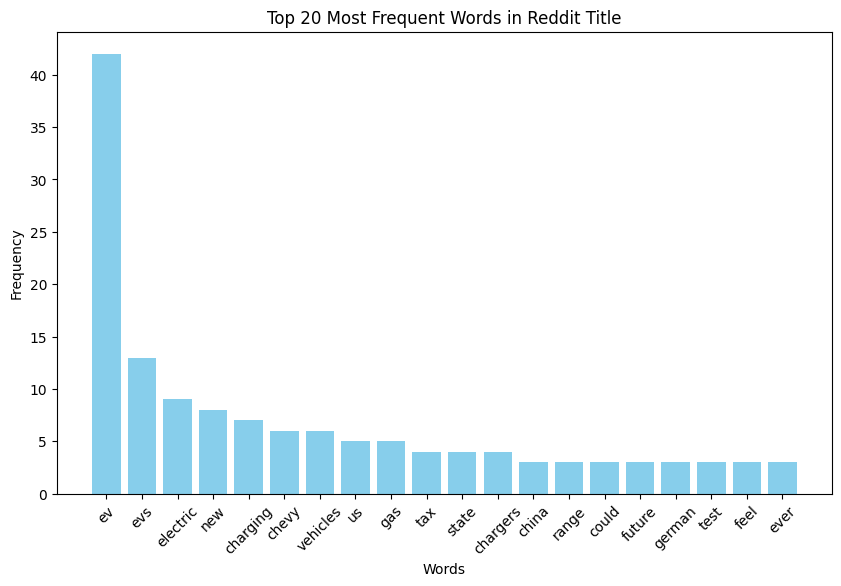

In [11]:
text = " ".join(reddit_data['title'].dropna().tolist()).lower()
top_n = 20
words = [word for word in text.split() if word.isalpha() and word not in stop_words]

word_counts = Counter(words)
most_common_words = word_counts.most_common(top_n)

words, counts = zip(*most_common_words)
plt.figure(figsize=(10, 6))
plt.bar(words, counts, color='skyblue')
plt.title(f"Top {top_n} Most Frequent Words in Reddit {'title'.capitalize()}")
plt.xlabel("Words")
plt.ylabel("Frequency")
plt.xticks(rotation=45)
plt.show()

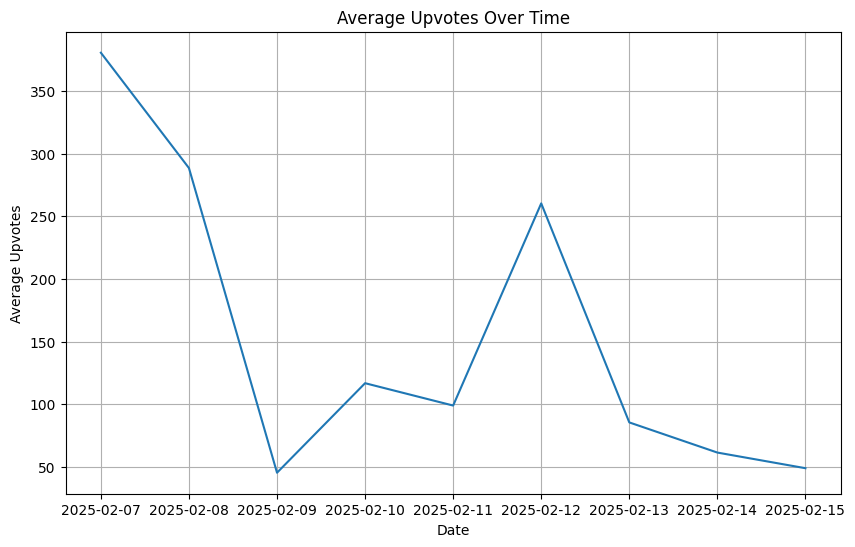

In [12]:
reddit_data['date'] = pd.to_datetime(reddit_data['date'], unit='s')

avg_upvotes = reddit_data.groupby(reddit_data['date'].dt.date)['upvotes'].mean()

plt.figure(figsize=(10, 6))
plt.plot(avg_upvotes.index, avg_upvotes.values)
plt.title("Average Upvotes Over Time")
plt.xlabel("Date")
plt.ylabel("Average Upvotes")
plt.grid(True)
plt.show()

# Wikipedia Data

In this section we are extracting data from wikipidea using the wikipidea api. We are extracting from the electric vehicle page and then counting the top words in the text extracted from the page.

In [13]:

topic = "Electric vehicle"
wiki_wiki = wikipediaapi.Wikipedia(
    language='en',
    user_agent='EV_Scrapping/1.0 (https://en.wikipedia.org/wiki/Electric_vehicle#; hashimshabbir752@gmail.com)'
    )

page = wiki_wiki.page(topic)

if page.exists():
    with open(f"wikipedia_{topic}_data.txt", "w", encoding="utf-8") as file:
        file.write(page.text)
    print(f"Wikipedia data for {topic} saved to text file.")

else:
    print(f"Wikipedia page for {topic} does not exist.")

Wikipedia data for Electric vehicle saved to text file.


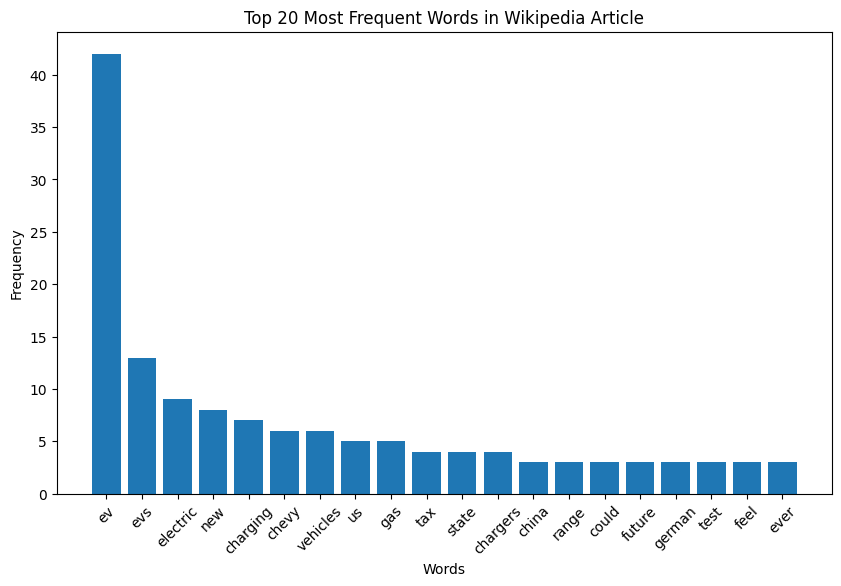

In [15]:

wikipedia_text = page.text
stop_words = set(stopwords.words('english'))

words = [word for word in text.split() if word.isalpha() and word.lower() not in stop_words]

word_counts = Counter(words)
most_common_words = word_counts.most_common(top_n)

words, counts = zip(*most_common_words)
plt.figure(figsize=(10, 6))
plt.bar(words, counts)
plt.title(f"Top {top_n} Most Frequent Words in Wikipedia Article")
plt.xlabel("Words")
plt.ylabel("Frequency")
plt.xticks(rotation=45)
plt.show()

# Yahoo Finance

In this section we are gonna be extracting the financial trends of different companies using yahoo finance api. We have chosen a few companies that work on electric vehicles such as Tesla, NIO,  BYD Company Limited, NextEra Energy etc. We will then plot trends of their stocks and returns

[*********************100%***********************]  6 of 6 completed


             TSLA         NIO       BYDDF         NEE        ENPH        PLUG
count  502.000000  502.000000  502.000000  502.000000  502.000000  502.000000
mean   238.161633    6.848426   30.060388   68.258758  123.483526    5.338645
std     67.714187    2.460967    3.960569    8.570444   40.097395    3.614389
min    142.050003    3.670000   21.657558   47.537640   59.520000    1.610000
25%    187.372505    4.632500   27.190650   61.351154  101.782501    2.410000
50%    222.995003    6.075000   29.915794   70.446186  117.009998    3.530000
75%    256.989990    8.507500   32.762430   73.974190  135.417500    8.410000
max    479.859985   15.460000   46.669998   84.861275  227.869995   16.770000


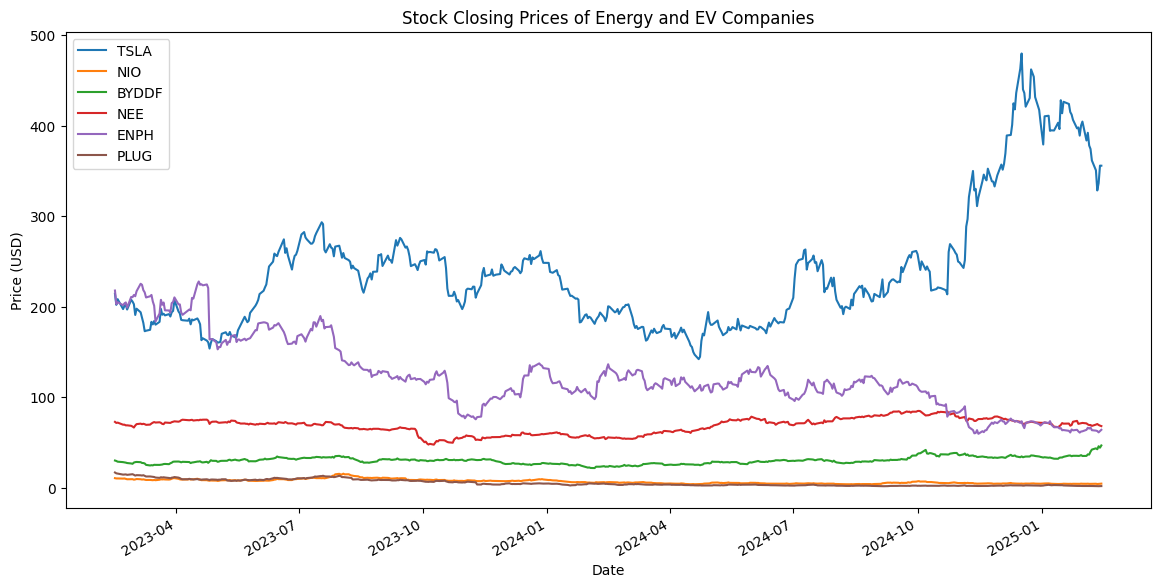

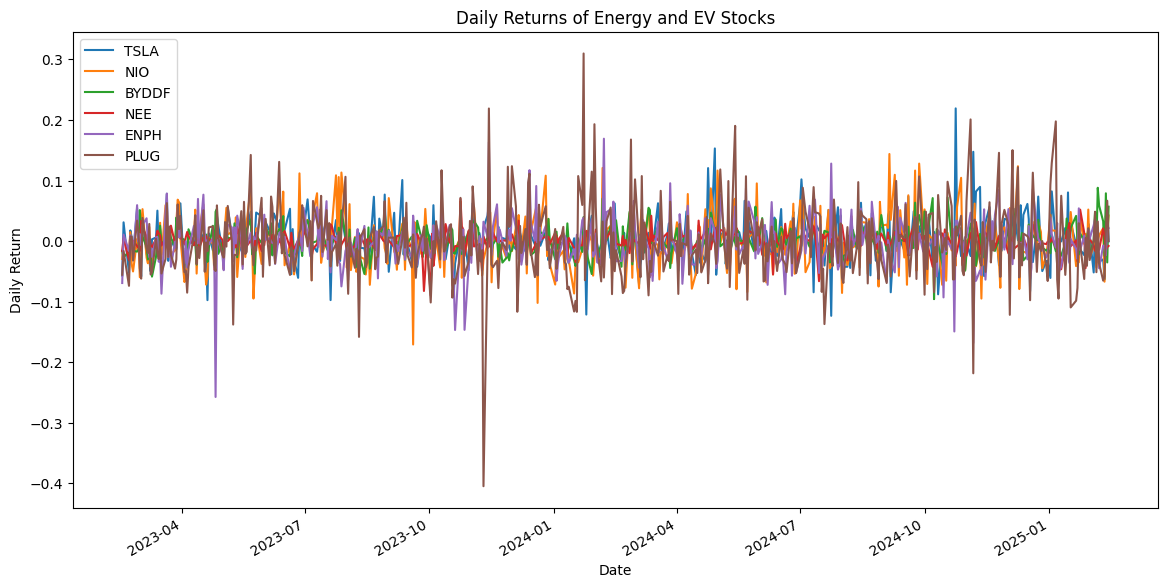

In [16]:
tickers = ['TSLA', 'NIO', 'BYDDF', 'NEE', 'ENPH', 'PLUG']

data = yf.download(tickers, start="2023-02-15", end="2025-02-15", group_by='ticker')

closing_prices = pd.DataFrame({ticker: data[ticker]['Close'] for ticker in tickers})

print(closing_prices.describe())

closing_prices.plot(figsize=(14, 7), title="Stock Closing Prices of Energy and EV Companies")
plt.xlabel("Date")
plt.ylabel("Price (USD)")
plt.legend(tickers)
plt.show()

daily_returns = closing_prices.pct_change()

daily_returns.plot(figsize=(14, 7), title="Daily Returns of Energy and EV Stocks")
plt.xlabel("Date")
plt.ylabel("Daily Return")
plt.show()

# Kaggle

In this section we are downloading the dataset from kaggle. This dataset contains the electric vehicle population. We can get insights into the number of electric vehicles in the market and their ratio within the market. Also we can make visuals on the types of EVs available.

In [17]:
!kaggle datasets download willianoliveiragibin/electric-vehicle-population

Dataset URL: https://www.kaggle.com/datasets/willianoliveiragibin/electric-vehicle-population
License(s): CC0-1.0
100% 4.71M/4.71M [00:00<00:00, 46.4MB/s]
100% 4.71M/4.71M [00:00<00:00, 46.2MB/s]


In [18]:
!unzip electric-vehicle-population.zip

Archive:  electric-vehicle-population.zip
  inflating: Electric_Vehicle_Population_Data.csv  


,VIN (1-10),County,City,State,Postal Code,Model Year,Make,Model,Electric Vehicle Type,Clean Alternative Fuel Vehicle (CAFV) Eligibility,Electric Range,Base MSRP,Legislative District,DOL Vehicle ID,Vehicle Location,Electric Utility,2020 Census Tract
0,KM8K33AGXL,King,Seattle,WA,98103.0,2020,HYUNDAI,KONA,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,258,0,43.0,249675142,POINT (-122.34301 47.659185),CITY OF SEATTLE - (WA)|CITY OF TACOMA - (WA),5.303300e+10
1,1C4RJYB61N,King,Bothell,WA,98011.0,2022,JEEP,GRAND CHEROKEE,Plug-in Hybrid Electric Vehicle (PHEV),Not eligible due to low battery range,25,0,1.0,233928502,POINT (-122.20578 47.762405),PUGET SOUND ENERGY INC||CITY OF TACOMA - (WA),5.303302e+10
2,1C4RJYD61P,Yakima,Yakima,WA,98908.0,2023,JEEP,GRAND CHEROKEE,Plug-in Hybrid Electric Vehicle (PHEV),Not eligible due to low battery range,25,0,14.0,229675939,POINT (-120.6027202 46.5965625),PACIFICORP,5.307700e+10
3,5YJ3E1EA7J,King,Kirkland,WA,98034.0,2018,TESLA,MODEL 3,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,215,0,45.0,104714466,POINT (-122.209285 47.71124),PUGET SOUND ENERGY INC||CITY OF TACOMA - (WA),5.303302e+10
4,WBY7Z8C5XJ,Thurston,Olympia,WA,98501.0,2018,BMW,I3,Plug-in Hybrid Electric Vehicle (PHEV),Clean Alternative Fuel Vehicle Eligible,97,0,22.0,185498386,POINT (-122.89692 47.043535),PUGET SOUND ENERGY INC,5.306701e+10


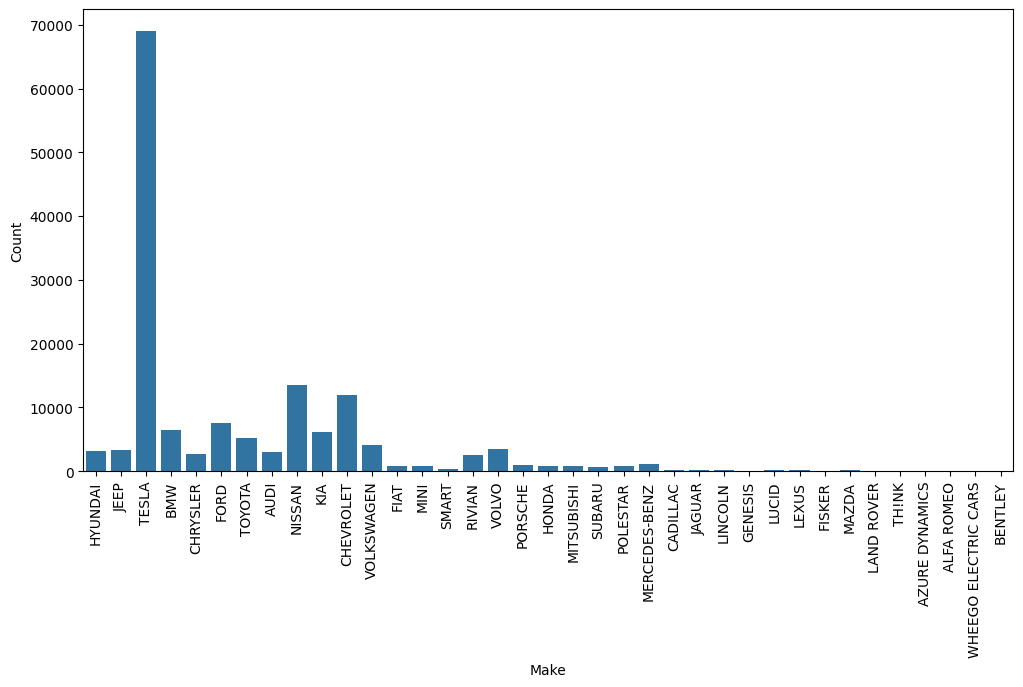

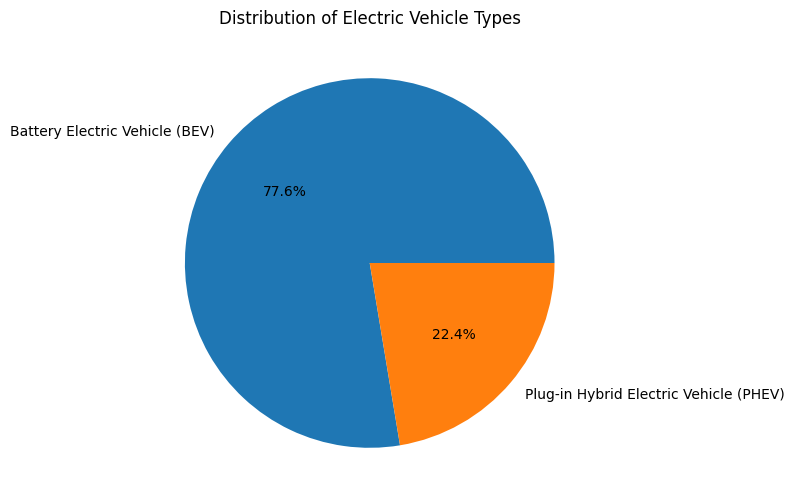

In [25]:
df = pd.read_csv('/content/Electric_Vehicle_Population_Data.csv')

display(df.head())

plt.figure(figsize=(12,6))
sns.countplot(data=df,x='Make')
plt.xticks(rotation=90)
plt.xlabel('Make')
plt.ylabel('Count')
plt.show()

plt.figure(figsize=(8, 6))
df['Electric Vehicle Type'].value_counts().plot.pie(autopct='%1.1f%%')
plt.title('Distribution of Electric Vehicle Types')
plt.ylabel('')
plt.show()